In [3]:
# -------------------- IMPORT --------------------
import pandas as pd

In [4]:
# -------------------- LOAD DATA --------------------
ds = pd.read_csv("advertising.csv")
print(ds.head())
print(ds.info())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None


In [5]:
# -------------------- CHECK NULLS --------------------
print("\nMissing Values:\n", ds.isnull().sum())


Missing Values:
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [6]:
# -------------------- FEATURES & TARGET --------------------
X = ds[['TV', 'Radio', 'Newspaper']]
y = ds['Sales']

In [7]:
# -------------------- TRAIN TEST SPLIT --------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [8]:
# -------------------- MODEL --------------------
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
# -------------------- COEFFICIENTS --------------------
print("\nModel Coefficients:")
for col, coef in zip(X.columns, model.coef_):
    print(f"{col}: {coef}")

print("Intercept:", model.intercept_)



Model Coefficients:
TV: 0.05450927083721977
Radio: 0.1009453623929558
Newspaper: 0.00433664682203402
Intercept: 4.714126402214131


In [10]:
# -------------------- EVALUATION --------------------
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

In [11]:
# Training
y_pred_train = model.predict(X_train)

print("\n--- Training Performance ---")
print("MSE:", mean_squared_error(y_train, y_pred_train))
print("RMSE:", sqrt(mean_squared_error(y_train, y_pred_train)))
print("R2 Score:", r2_score(y_train, y_pred_train))



--- Training Performance ---
MSE: 2.676142653782668
RMSE: 1.6358920055378559
R2 Score: 0.9001416005862131


In [12]:
# Testing
y_pred_test = model.predict(X_test)

print("\n--- Testing Performance ---")
print("MSE:", mean_squared_error(y_test, y_pred_test))
print("R2 Score:", r2_score(y_test, y_pred_test))


--- Testing Performance ---
MSE: 2.907756910271092
R2 Score: 0.9059011844150826


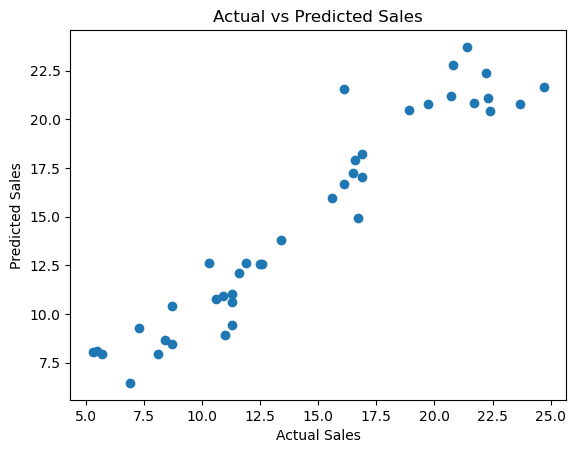

In [13]:
# -------------------- VISUALIZATION --------------------
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [14]:
# -------------------- USER INPUT --------------------
print("\n--- Enter Advertising Budget ---")

tv = float(input("TV Budget: "))
radio = float(input("Radio Budget: "))
newspaper = float(input("Newspaper Budget: "))

input_df = pd.DataFrame([{
    "TV": tv,
    "Radio": radio,
    "Newspaper": newspaper
}])


--- Enter Advertising Budget ---


TV Budget:  300
Radio Budget:  60
Newspaper Budget:  79


In [15]:
prediction = model.predict(input_df)

print("\nPredicted Sales:", round(prediction[0], 2))


Predicted Sales: 27.47
